In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from lokan import *
from lokan import loKAN

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# **Dataset** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ and 2 learnable prod group

In [3]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
  
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

In [4]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, batch_size=512, epochs=1000):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    def relative_mse_loss(y_pred, y_true, epsilon=1e-8):
        # (batch_size, out_dim)
        squared_diff = (y_pred - y_true)**2
        # Нормализуем на квадрат истинного значения
        relative_diff = squared_diff / (y_true**2 + epsilon)
        return torch.mean(relative_diff)

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-6  # для L1 активаций 1.
    lamb_ent_acts = 1e-3  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
                    
            new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            # train_loss = relative_mse_loss(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=1.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            # test_loss = relative_mse_loss(test_outputs, dataset['test_label'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            # for module in model.modules():
            #     if isinstance(module, NexusKANLayer):
            #         probs = torch.softmax(module.logits / module.tau, dim=-1)
            #         rounded_probs = probs.round(decimals=3)
            #         print(rounded_probs)
        

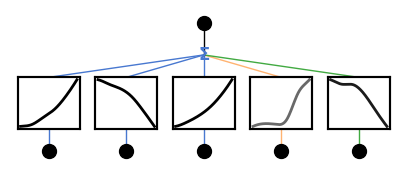

In [5]:
model = loKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [6]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

Epoch [10/100], Train Loss: 0.1252, Test Loss: 0.1319
Epoch [20/100], Train Loss: 0.0013, Test Loss: 0.0014
Epoch [30/100], Train Loss: 0.0008, Test Loss: 0.0009
Epoch [40/100], Train Loss: 0.0008, Test Loss: 0.0008
Epoch [50/100], Train Loss: 0.0007, Test Loss: 0.0007
Epoch [60/100], Train Loss: 0.0007, Test Loss: 0.0005
Epoch [70/100], Train Loss: 0.0007, Test Loss: 0.0005
Epoch [80/100], Train Loss: 0.0007, Test Loss: 0.0005
Epoch [90/100], Train Loss: 0.0007, Test Loss: 0.0005
Epoch [100/100], Train Loss: 0.0006, Test Loss: 0.0005


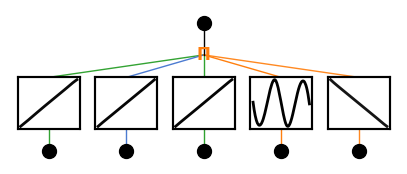

In [7]:
model.plot()

In [8]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[-2.6525, -1.6584, -0.7776, -0.0974,  0.1344,  0.1104, -0.1252,
          -1.1615]],

        [[-2.2927, -1.4311, -0.7843, -0.2210,  0.2333,  0.5550,  0.7951,
           1.0388]],

        [[-2.6347, -1.5360, -0.7609, -0.1721,  0.1773,  0.2659,  0.2384,
          -0.3552]],

        [[ 6.2318, -1.1462, -0.9821,  2.1009, -2.1068,  0.9804,  1.1092,
          -6.0277]],

        [[ 2.6635,  1.3734,  0.6662,  0.1156, -0.1432, -0.1231,  0.0375,
           0.7017]]], device='cuda:0')
act_fun.0.scale_base tensor([[ 1.3784],
        [ 0.7864],
        [ 1.3661],
        [ 0.0321],
        [-1.1371]], device='cuda:0')
act_fun.0.scale_sp tensor([[0.3381],
        [0.5435],
        [0.4444],
        [1.4279],
        [0.3425]], device='cuda:0')
act_fun.0.logits tensor([[[-0.4734,  6.4776, -2.0830]],

        [[-1.6431, -1.8521,  3.1118]],

        [[-1.3193,  6.2828, -2.1542]],

        [[ 6.1809, -0.9842, -2.1198]],

        [[ 7.0772, -0.9664, -2.5822]]], device='cuda:0'

In [9]:
for module in model.modules():
    if isinstance(module, LOKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1., 0.]],

        [[0., 0., 1.]],

        [[0., 1., 0.]],

        [[1., 0., 0.]],

        [[1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)


# **Dataset** $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$ 

## LBFGS

In [ ]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, epochs=1000, 
                    logits_requires_grad=True, splines_requires_grad=True,
                    use_full_batch=True, batch_size=512):
    """
    Обучение модели с оптимизатором LBFGS.
    
    Args:
        use_full_batch: если True — используется весь датасет за шаг (рекомендуется для LBFGS)
                        если False — эмуляция mini-batch (менее стабильно)
    """
    # Инициализация LBFGS
    optimizer = optim.LBFGS(model.parameters(), 
                           lr=lr, 
                           history_size=10, 
                           line_search_fn="strong_wolfe", 
                           tolerance_grad=1e-32, 
                           tolerance_change=1e-32)
    criterion = nn.MSELoss()
    
    lamb_l1_acts = 1e-3
    lamb_ent_acts = 1e-3

    for epoch in range(epochs):
        # === Обновление гиперпараметров (раз в эпоху, не внутри closure!) ===
        current_lr = lr
        # current_lr = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
        new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
        
        # Обновление requires_grad и tau для слоёв модели
        for module in model.modules():
            if isinstance(module, LOKANLayer):
                module.logits.requires_grad = logits_requires_grad
                module.scale_base.requires_grad = splines_requires_grad
                module.scale_sp.requires_grad = splines_requires_grad
                module.coef.requires_grad = splines_requires_grad
                module.tau = new_tau
        
        # Обновление learning rate в оптимизаторе
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
        
        # === Функция closure для LBFGS ===
        def closure():
            optimizer.zero_grad()
            
            if use_full_batch:
                # Полный датасет (рекомендуется)
                batch_x = dataset['train_input']
                batch_y = dataset['train_label']
            else:
                # Эмуляция mini-batch (не рекомендуется для LBFGS)
                idx = torch.randperm(dataset['train_input'].shape[0])[:batch_size]
                batch_x = dataset['train_input'][idx]
                batch_y = dataset['train_label'][idx]
            
            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            # lamb_ent_ops = 10.0
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # === Регуляризация активаций (L1 + энтропия) ===
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            loss.backward()
            return loss
        
        # === Шаг оптимизации ===
        optimizer.step(closure)
        
        # === Оценка на тесте ===
        with torch.no_grad():
            train_out = model(dataset['train_input'])
            train_loss = criterion(train_out, dataset['train_label'])
            test_out = model(dataset['test_input'])
            test_loss = criterion(test_out, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'--- Epoch [{epoch+1}/{epochs}], '
                  f'Train Loss: {train_loss.item():.4f}, '
                  f'Test Loss: {test_loss.item():.4f}')

## Adam

In [10]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_tau_osc(step, total_steps, tau_start=2.0, tau_sup=1.0, tau_end=0.1, freq=7.0):
    top_th = tau_start * (tau_end / tau_start) ** (step / total_steps)
    bottom_th = tau_sup * (tau_end / tau_sup) ** (step / total_steps)
    osc = (top_th + bottom_th) + (top_th - bottom_th) * np.cos(freq * torch.pi * step / total_steps)
    return osc / 2

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

# def get_lamb_osc(step, total_steps, tau_start=2.0, tau_sup=1.0, tau_end=0.1, freq=3.0):
#     top_th = tau_start * (tau_end / tau_start) ** (step / total_steps)
#     bottom_th = tau_sup * (tau_end / tau_sup) ** (step / total_steps)
#     osc = (top_th + bottom_th) - (top_th - bottom_th) * np.cos(freq * torch.pi * step / total_steps)
#     return osc / 2

def fit_model(model, dataset, lr=0.1, batch_size=64, epochs=100, logits_requires_grad=True, splines_requires_grad=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    def relative_mse_loss(y_pred, y_true, epsilon=1e-8):
        # (batch_size, out_dim)
        squared_diff = (y_pred - y_true)**2
        # Нормализуем на квадрат истинного значения
        relative_diff = squared_diff / (y_true**2 + epsilon)
        return torch.mean(relative_diff)
        

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-3  # для L1 активаций 1.
    lamb_ent_acts = 1e-3  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
            
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    module.logits.requires_grad = logits_requires_grad
                    
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    module.scale_base.requires_grad = splines_requires_grad
                    module.scale_sp.requires_grad = splines_requires_grad
                    module.coef.requires_grad = splines_requires_grad
                   
            # new_tau = 2.0 
            new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            # train_loss = criterion(outputs, batch_y)
            train_loss = relative_mse_loss(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            # lamb_ent_ops = 10.0
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            # loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = relative_mse_loss(test_outputs, dataset['test_label'])
            # test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'--- Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            # for module in model.modules():
            #     if isinstance(module, LOKANLayer):
            #         probs = torch.softmax(module.logits / module.tau, dim=-1)
            #         rounded_probs = probs.round(decimals=3)
            #         print("tau: ", module.tau)
            #         print(rounded_probs)

## **Test 0:** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ (don`t work with relative MSE)

In [12]:
end_range = 1.0
start_range = 0.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
  
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

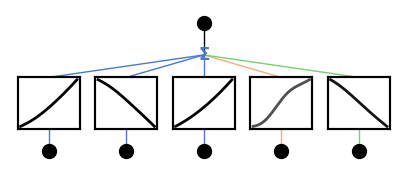

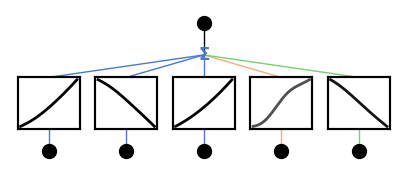

In [13]:
model = loKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [14]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 1.0978, Test Loss: 1.2999
--- Epoch [20/100], Train Loss: 1.0435, Test Loss: 1.0924
--- Epoch [30/100], Train Loss: 1.0096, Test Loss: 1.0149
--- Epoch [40/100], Train Loss: 0.9927, Test Loss: 0.9885
--- Epoch [50/100], Train Loss: 0.9880, Test Loss: 0.9830
--- Epoch [60/100], Train Loss: 0.9878, Test Loss: 0.9841
--- Epoch [70/100], Train Loss: 0.9875, Test Loss: 0.9901
--- Epoch [80/100], Train Loss: 0.9878, Test Loss: 1.0039
--- Epoch [90/100], Train Loss: 0.9968, Test Loss: 1.0120
--- Epoch [100/100], Train Loss: 1.0053, Test Loss: 1.0165


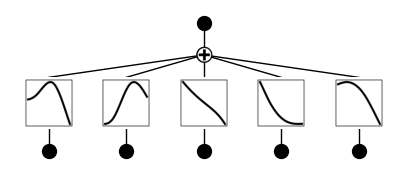

In [7]:
model.plot()

In [8]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[1.0000, 0.0000, 0.0000]],

        [[0.9980, 0.0020, 0.0000]],

        [[0.0000, 1.0000, 0.0000]],

        [[1.0000, 0.0000, 0.0000]],

        [[0.0000, 1.0000, 0.0000]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 1 :** $y = \frac{x_0}{x_1} + \frac{x_2}{x_3}$

In [11]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

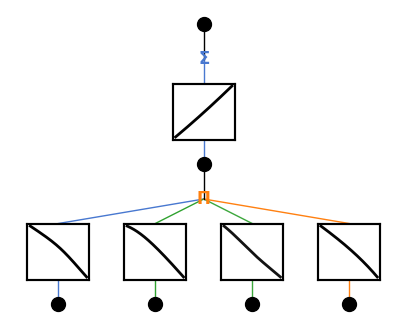

In [12]:
model = loKAN(width=[4, 1, 1], grid=5, k=3, seed=42, 
                #  grid_range=[0.5, 4.0], 
                 device=device)
model(dataset['train_input'])
model.plot()

In [13]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0182, Test Loss: 0.0248
--- Epoch [20/100], Train Loss: 0.0027, Test Loss: 0.0033
--- Epoch [30/100], Train Loss: 0.0018, Test Loss: 0.0025
--- Epoch [40/100], Train Loss: 0.0017, Test Loss: 0.0020
--- Epoch [50/100], Train Loss: 0.0016, Test Loss: 0.0018
--- Epoch [60/100], Train Loss: 0.0015, Test Loss: 0.0017
--- Epoch [70/100], Train Loss: 0.0014, Test Loss: 0.0017
--- Epoch [80/100], Train Loss: 0.0013, Test Loss: 0.0016
--- Epoch [90/100], Train Loss: 0.0013, Test Loss: 0.0016
--- Epoch [100/100], Train Loss: 0.0013, Test Loss: 0.0016


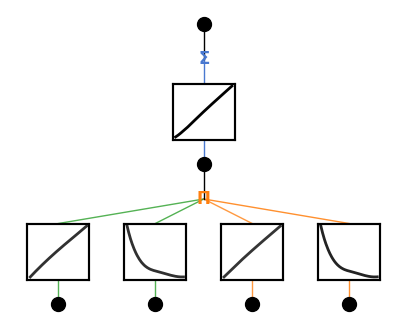

In [14]:
model.plot()

In [15]:
for module in model.modules():
    if isinstance(module, LOKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1., 0.]],

        [[0., 1., 0.]],

        [[1., 0., 0.]],

        [[1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 2 :** $y = \frac{x_0}{x_1}$

In [16]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 2) + start_range
# x[:, 1] = 0.5

y = x[:, 0] / x[:, 1]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

In [17]:
model = loKAN(width=[2, 1, 1], grid=5, k=3, seed=42, 
                #  grid_range=[0.5, 4.0], 
                 device=device)

In [18]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0010, Test Loss: 0.0012
--- Epoch [20/100], Train Loss: 0.0004, Test Loss: 0.0007
--- Epoch [30/100], Train Loss: 0.0003, Test Loss: 0.0006
--- Epoch [40/100], Train Loss: 0.0003, Test Loss: 0.0005
--- Epoch [50/100], Train Loss: 0.0003, Test Loss: 0.0004
--- Epoch [60/100], Train Loss: 0.0004, Test Loss: 0.0004
--- Epoch [70/100], Train Loss: 0.0004, Test Loss: 0.0004
--- Epoch [80/100], Train Loss: 0.0004, Test Loss: 0.0003
--- Epoch [90/100], Train Loss: 0.0004, Test Loss: 0.0003
--- Epoch [100/100], Train Loss: 0.0004, Test Loss: 0.0002


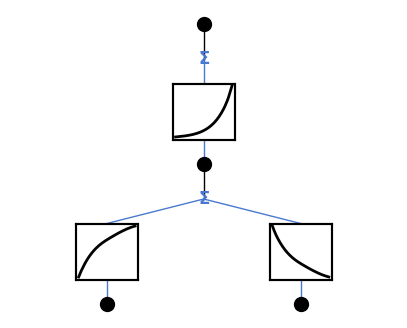

In [19]:
model.plot()

In [20]:
for module in model.modules():
    if isinstance(module, LOKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.1610, 0.8390]],

        [[0.1790, 0.8210]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


In [21]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[ 1.1586e-02,  3.6656e-02, -1.2244e+01, -2.7530e+00, -4.5343e-01,
          -1.4503e-01,  4.0416e-02, -2.7305e-01]],

        [[ 4.0875e-03,  2.7029e-02,  2.9384e+01,  3.3477e+00,  1.0446e-01,
          -3.1695e-01, -5.5386e-01, -9.2660e-02]]], device='cuda:0')
act_fun.0.scale_base tensor([[ 0.6163],
        [-0.6519]], device='cuda:0')
act_fun.0.scale_sp tensor([[0.8304],
        [0.5916]], device='cuda:0')
act_fun.0.logits tensor([[[0.5001, 0.6704]],

        [[0.6511, 0.8082]]], device='cuda:0')
act_fun.1.coef tensor([[[0.0945, 0.1637, 0.2680, 0.4849, 0.9599, 1.9608, 3.9788, 9.1913]]],
       device='cuda:0')
act_fun.1.scale_base tensor([[0.3121]], device='cuda:0')
act_fun.1.scale_sp tensor([[1.5232]], device='cuda:0')
act_fun.1.logits tensor([[[0.2695]]], device='cuda:0')
symbolic_fun.0.affine tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.]]], device='cuda:0')
symbolic_fun.1.affine tensor([[[0., 0., 0., 0.]]], device='cuda:0')


## **Test 3 :** $y = \frac{\frac{x_0}{x_1}}{\frac{x_2}{x_3}}$

In [22]:
end_range = 3.0
start_range = 1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] / x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

In [23]:
model = loKAN(width=[4, 2, 1], grid=5, k=3, seed=42, grid_range=[0.5, 4.0], device=device)

In [24]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0001, Test Loss: 0.0004
--- Epoch [20/100], Train Loss: 0.0000, Test Loss: 0.0001
--- Epoch [30/100], Train Loss: 0.0000, Test Loss: 0.0001
--- Epoch [40/100], Train Loss: 0.0001, Test Loss: 0.0003
--- Epoch [50/100], Train Loss: 0.0000, Test Loss: 0.0002
--- Epoch [60/100], Train Loss: 0.0001, Test Loss: 0.0001
--- Epoch [70/100], Train Loss: 0.0000, Test Loss: 0.0001
--- Epoch [80/100], Train Loss: 0.0000, Test Loss: 0.0001
--- Epoch [90/100], Train Loss: 0.0001, Test Loss: 0.0001
--- Epoch [100/100], Train Loss: 0.0000, Test Loss: 0.0000


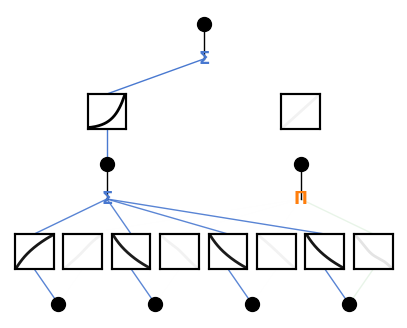

In [25]:
model.plot()

In [26]:
for module in model.modules():
    if isinstance(module, LOKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.0440, 0.0060, 0.9500],
         [0.0000, 1.0000, 0.0000]],

        [[0.0000, 0.0000, 1.0000],
         [0.2690, 0.7310, 0.0000]],

        [[0.0000, 0.0000, 1.0000],
         [0.0090, 0.9910, 0.0000]],

        [[0.0000, 0.0000, 1.0000],
         [0.0010, 0.9990, 0.0000]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[0.0010, 0.9990]],

        [[0.6350, 0.3650]]], device='cuda:0', grad_fn=<RoundBackward1>)


## $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$

In [34]:
end_range = 2.0
start_range = 0.3
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 8) + start_range

# x[:, 1] = 5.5
# x[:, 3] = 6.4
# x[:, 5] = 8.5
# x[:, 7] = 7.6

y = (x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]) / (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7])

dataset = {
    'train_input': x[:num_samples],
    'train_label': y[:num_samples].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 8]), torch.Size([1000, 1]))

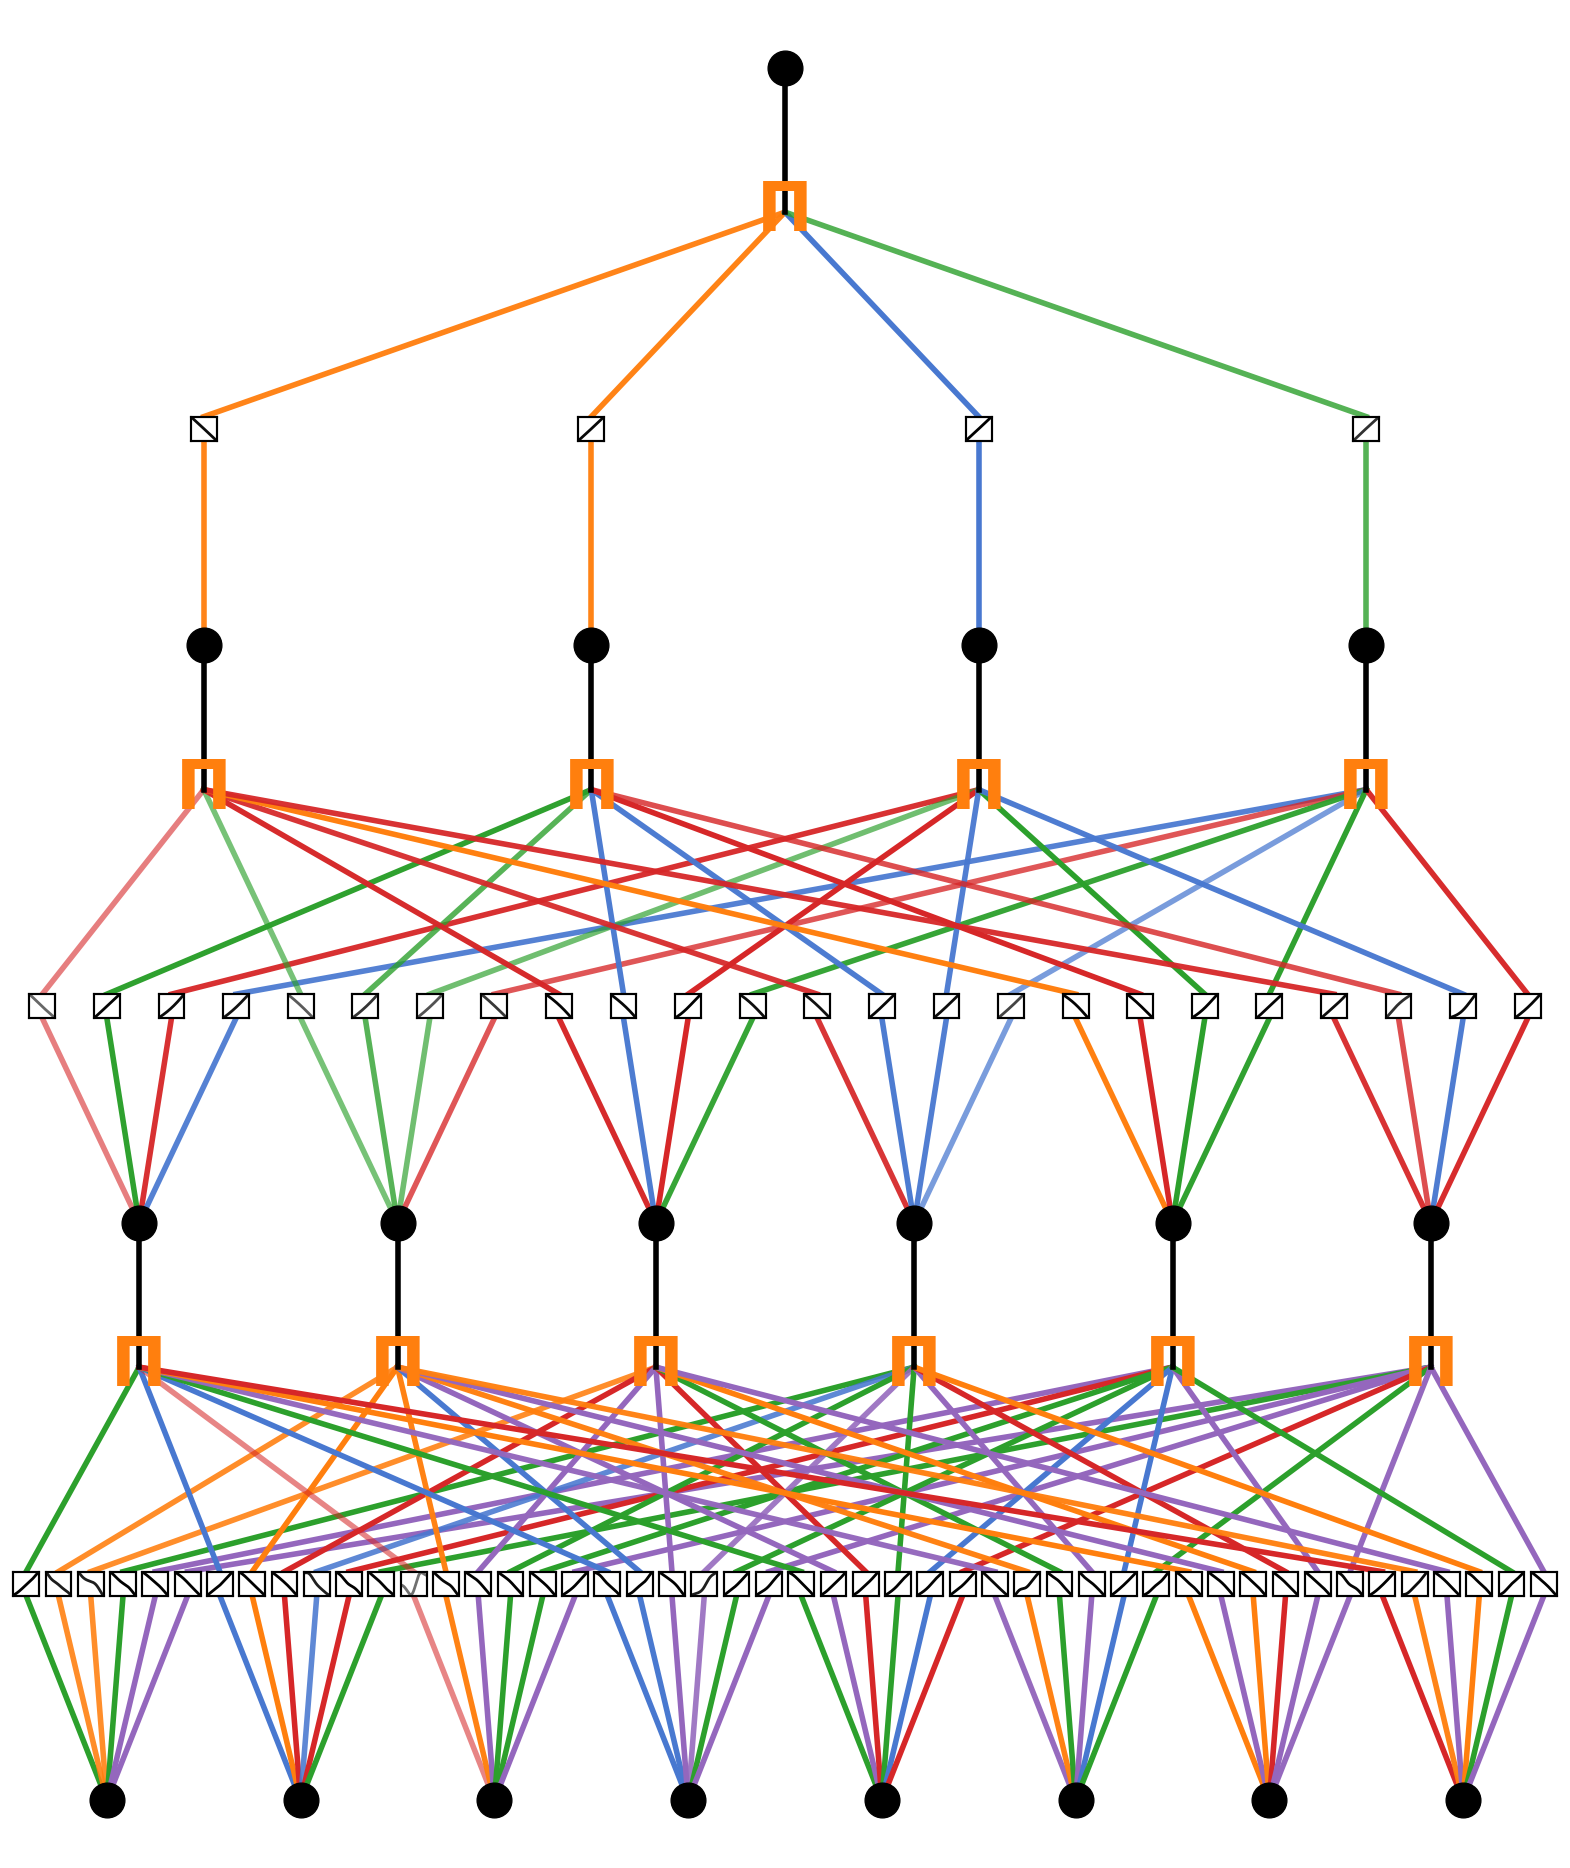

In [35]:
model = loKAN(width=[8, 6, 4, 1], grid=5, k=3, seed=42, 
                 grid_range=[0.1, 2.5],
                 device=device)
model(dataset['train_input'])
model.plot(scale=2.0)

In [36]:
fit_model(model=model, 
          dataset=dataset,
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0092, Test Loss: 0.0111
--- Epoch [20/100], Train Loss: 0.0057, Test Loss: 0.0062
--- Epoch [30/100], Train Loss: 0.0045, Test Loss: 0.0055
--- Epoch [40/100], Train Loss: 0.0054, Test Loss: 0.0066
--- Epoch [50/100], Train Loss: 0.0033, Test Loss: 0.0058
--- Epoch [60/100], Train Loss: 0.0038, Test Loss: 0.0047
--- Epoch [70/100], Train Loss: 0.0028, Test Loss: 0.0051
--- Epoch [80/100], Train Loss: 0.0027, Test Loss: 0.0044
--- Epoch [90/100], Train Loss: 0.0034, Test Loss: 0.0048
--- Epoch [100/100], Train Loss: 0.0032, Test Loss: 0.0042


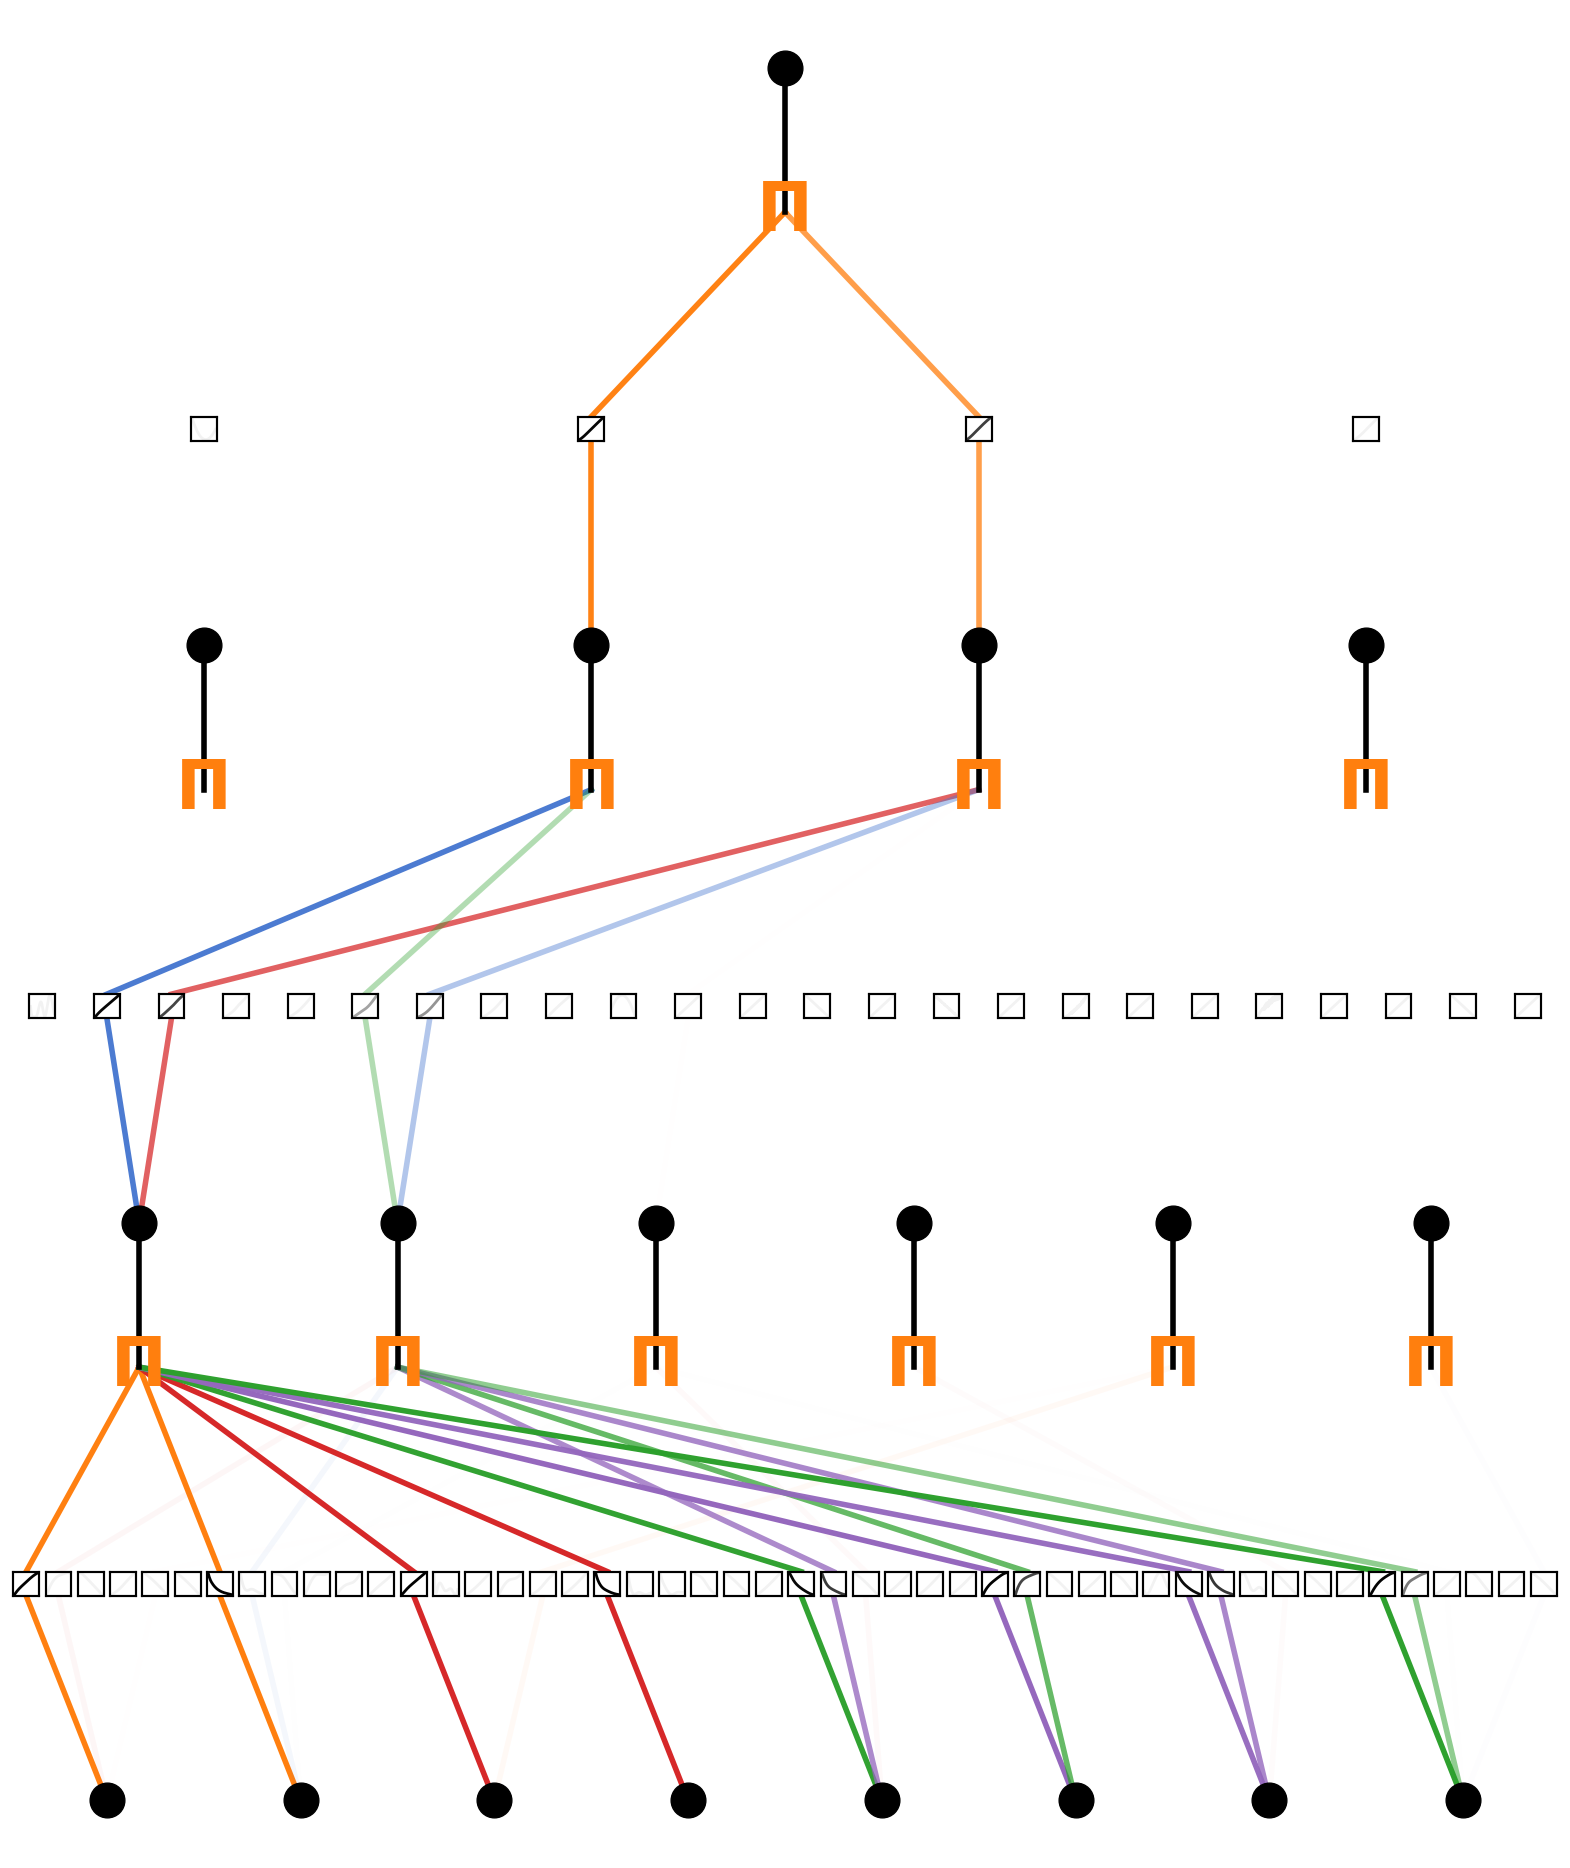

In [37]:
model.plot(scale=2.0)

In [38]:
for module in model.modules():
    if isinstance(module, LOKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.5870, 0.2150, 0.0000, 0.1980, 0.0000],
         [0.0010, 0.1230, 0.8660, 0.0000, 0.0100],
         [1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0090, 0.0020, 0.9900, 0.0000, 0.0000],
         [1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [1.0000, 0.0000, 0.0000, 0.0000, 0.0000]],

        [[0.5540, 0.2160, 0.0000, 0.2300, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
         [0.0000, 0.0000, 1.0000, 0.0000, 0.0000],
         [0.3970, 0.0320, 0.5240, 0.0470, 0.0000],
         [0.1940, 0.8050, 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.1890, 0.5920, 0.2110, 0.0070],
         [1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 1.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0020, 0.0000, 0.9980, 0.0000],
         [1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 1.0000, 0.0000]],

        [[0.0000, 0.2170, 0.5240, 0.2090, 0.0500],
         [1.0000, 0.0000,